# Figure 4 — NDVI histograms for historical wetlands vs. adjacent uplands (Corn & Soy, 2021)

This notebook reproduces the two-column histogram figure: left column = Corn cohort, right column = Soy cohort.
Rows are months (May–September). For each panel, we overlay histograms of NDVI for **Historical Wetlands** (blue)
and **Adjacent Uplands** (green for corn, orange for soy).


[2018-05] EVI2 Corn — wetlands n=72,391, upland-pooled n=72,391
[2018-05] EVI2 Soy — wetlands n=47,986, upland-pooled n=47,986
[2018-06] EVI2 Corn — wetlands n=68,425, upland-pooled n=68,425
[2018-06] EVI2 Soy — wetlands n=45,289, upland-pooled n=45,289
[2018-07] EVI2 Corn — wetlands n=72,406, upland-pooled n=72,406
[2018-07] EVI2 Soy — wetlands n=47,967, upland-pooled n=47,967
[2018-08] EVI2 Corn — wetlands n=72,389, upland-pooled n=72,389
[2018-08] EVI2 Soy — wetlands n=47,986, upland-pooled n=47,986
[2018-09] EVI2 Corn — wetlands n=15,300, upland-pooled n=15,300
[2018-09] EVI2 Soy — wetlands n=10,285, upland-pooled n=10,285
[OK] Saved → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/Figures/Figure 4/Figure 4.jpg


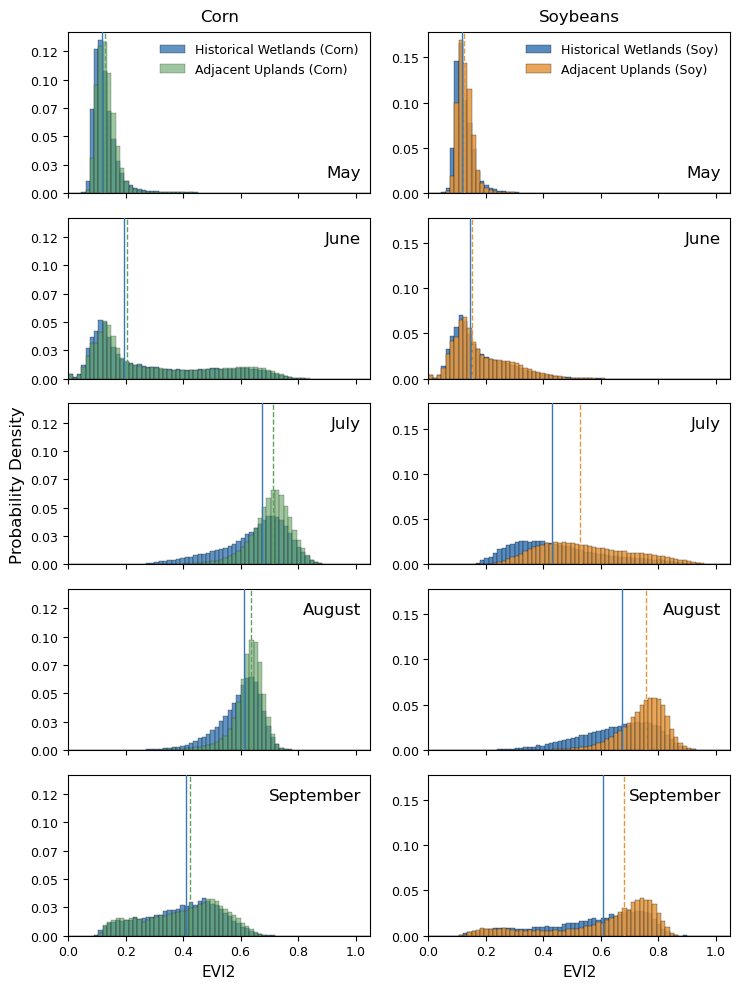

In [12]:
#updated 12/9, trying as pdfs instead of histograms

#!/usr/bin/env python3
# Monthly wetland vs upland EVI2 (or NDVI) histograms as PDFs
# Updated 2025-12-09: density=True (PDFs) + existing aesthetics

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os

# ---------------------
# USER SETTINGS
# ---------------------
YEAR   = 2018
MONTHS = ["05", "06", "07", "08", "09"]  # May–Sept
LABELS = {"05":"May","06":"June","07":"July","08":"August","09":"September"}

# Options: "NDVI" or "EVI2"
METRIC = "EVI2"

if METRIC not in {"NDVI", "EVI2"}:
    raise ValueError("METRIC must be 'NDVI' or 'EVI2'.")

ROOT       = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
POOLED_DIR = ROOT / "NDVI_wetlands"

PAPER_ROOT = Path(os.environ.get("DML_GDRIVE_ROOT", "./gdrive")) / "Research/Daily Work 2026/2026 Paper Submissions/Wetland Legacies"

OUTFIG = ROOT / "Figures" / "Figure 4" / "Figure 4.jpg"
OUTFIG.parent.mkdir(parents=True, exist_ok=True)

OUTFIG_paper = PAPER_ROOT / "Figures" / "Fig_3_monthly_EVI2.jpg"

FIGSIZE = (7.5, 10.0)
BINS = np.linspace(0.0, 1.05, 71)  # 70 bins

WETLAND_COLOR  = "#3A78B5"  # blue
CORN_ADJ_COLOR = "#5FA35F"  # green
SOY_ADJ_COLOR  = "#E5973E"  # orange

EDGE_KW = dict(edgecolor="black", linewidth=0.25)


def get_value_columns(df: pd.DataFrame, metric: str):
    """Return (wet_col, upl_col) to use for plotting."""
    if metric == "NDVI":
        return "wet_med", "upl_med"

    # METRIC == "EVI2"
    wet_candidates = ["wet_evi2_med", "wet_e2_med"]
    upl_candidates = ["upl_evi2_med", "upl_e2_med"]

    wet_col = next((c for c in wet_candidates if c in df.columns), None)
    upl_col = next((c for c in upl_candidates if c in df.columns), None)

    if wet_col is None or upl_col is None:
        raise KeyError(
            f"Could not find EVI2 median columns. "
            f"Looked for wet in {wet_candidates}, upl in {upl_candidates}. "
            f"Columns present: {list(df.columns)}"
        )

    return wet_col, upl_col


def load_pooled(year: int, month: str, crop: str) -> pd.DataFrame | None:
    """
    Read the pooled CSV (one row per wetland, dir=='ALL').
    Adds 'wet_val' and 'upl_val' columns to use for plotting.
    """
    path = POOLED_DIR / f"upland_rasteronly_{crop}_{year}_{month}_pooled.csv"
    if not path.exists():
        print(f"[SKIP] Missing pooled CSV for {year}-{month} {crop}: {path.name}")
        return None

    df = pd.read_csv(path)

    if "dir" in df.columns:
        df = df[df["dir"] == "ALL"].copy()

    wet_col, upl_col = get_value_columns(df, METRIC)

    df = df[np.isfinite(df[wet_col]) & np.isfinite(df[upl_col])].copy()

    df["wet_val"] = df[wet_col]
    df["upl_val"] = df[upl_col]

    df["month"] = month
    df["crop"]  = crop
    return df


# Load data
corn_dfs, soy_dfs = [], []
for mm in MONTHS:
    corn = load_pooled(YEAR, mm, "corn")
    soy  = load_pooled(YEAR, mm, "soy")
    if corn is not None:
        corn_dfs.append(corn)
    if soy is not None:
        soy_dfs.append(soy)

months_avail = sorted(set(
    [*( [d["month"].iloc[0] for d in corn_dfs] if corn_dfs else [] ),
     *( [d["month"].iloc[0] for d in soy_dfs]  if soy_dfs  else [] )]
))

if not months_avail:
    raise RuntimeError(
        f"No pooled CSVs found for the requested months for {METRIC}. "
        f"Check that pooled CSVs exist in {POOLED_DIR}."
    )

# Figure grid
nrows = len(months_avail)
ncols = 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=FIGSIZE, sharex=True)
if nrows == 1:
    axes = np.array([axes])  # keep 2D

# Column titles ONLY (not per subplot)
axes[0, 0].set_title("Corn", fontsize=12, pad=8)
axes[0, 1].set_title("Soybeans", fontsize=12, pad=8)


def get_df(crop: str, month: str) -> pd.DataFrame | None:
    lst = corn_dfs if crop == "corn" else soy_dfs
    for d in lst:
        if d["month"].iloc[0] == month:
            return d
    return None


corn_ymax = 0.0
soy_ymax  = 0.0

# Plot
for r, mm in enumerate(months_avail):
    month_name = LABELS.get(mm, mm)

    # =========================
    # Corn (left column)
    # =========================
    ax = axes[r, 0]
    dfc = get_df("corn", mm)

    # Month label (dynamic location: May in lower-right, others upper-right)
    x_pos, y_pos = 0.97, 0.92
    va = "top"
    if month_name == "May":
        x_pos, y_pos = 0.97, 0.08
        va = "bottom"

    ax.text(
        x_pos, y_pos,
        month_name,
        transform=ax.transAxes,
        fontsize=12,
        ha="right",
        va=va,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1),
    )

    if dfc is not None and not dfc.empty:
        wet_vals = dfc["wet_val"].values
        upl_vals = dfc["upl_val"].values

        # Histograms as PDFs (density=True)
        ax.hist(
            wet_vals,
            bins=BINS,
            histtype="bar",
            color=WETLAND_COLOR,
            alpha=0.8,
            zorder=1,
            label="Historical Wetlands (Corn)" if r == 0 else None,
            density=True,
            **EDGE_KW,
        )
        ax.hist(
            upl_vals,
            bins=BINS,
            histtype="bar",
            color=CORN_ADJ_COLOR,
            alpha=0.6,
            zorder=2,
            label="Adjacent Uplands (Corn)" if r == 0 else None,
            density=True,
            **EDGE_KW,
        )

        # Median lines
        w_med = np.median(wet_vals)
        u_med = np.median(upl_vals)
        ax.axvline(w_med, color=WETLAND_COLOR, linestyle='-',  linewidth=1.0, zorder=3)
        ax.axvline(u_med, color=CORN_ADJ_COLOR, linestyle='--', linewidth=1.0, zorder=3)

        # Track y max for consistent scaling (in density units)
        corn_ymax = max(corn_ymax, ax.get_ylim()[1])

        n_w = len(wet_vals)
        n_u = len(upl_vals)
        print(f"[{YEAR}-{mm}] {METRIC} Corn — wetlands n={n_w:,}, upland-pooled n={n_u:,}")
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)

    if r == int(np.floor(nrows / 2)):
        ax.set_ylabel("Probability Density", fontsize=12)
    if r == nrows - 1:
        ax.set_xlabel(METRIC, fontsize=11)
    if r == 0:
        ax.legend(frameon=False, fontsize=9, loc="upper right")

    # =========================
    # Soy (right column)
    # =========================
    ax = axes[r, 1]
    dfs = get_df("soy", mm)

    # Month label (same rules)
    x_pos, y_pos = 0.97, 0.92
    va = "top"
    if month_name == "May":
        x_pos, y_pos = 0.97, 0.08
        va = "bottom"

    ax.text(
        x_pos, y_pos,
        month_name,
        transform=ax.transAxes,
        fontsize=12,
        ha="right",
        va=va,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1),
    )

    if dfs is not None and not dfs.empty:
        wet_vals = dfs["wet_val"].values
        upl_vals = dfs["upl_val"].values

        # Histograms as PDFs (density=True)
        ax.hist(
            wet_vals,
            bins=BINS,
            histtype="bar",
            color=WETLAND_COLOR,
            alpha=0.85,
            zorder=1,
            label="Historical Wetlands (Soy)" if r == 0 else None,
            density=True,
            **EDGE_KW,
        )
        ax.hist(
            upl_vals,
            bins=BINS,
            histtype="bar",
            color=SOY_ADJ_COLOR,
            alpha=0.85,
            zorder=2,
            label="Adjacent Uplands (Soy)" if r == 0 else None,
            density=True,
            **EDGE_KW,
        )

        # Median lines
        w_med = np.median(wet_vals)
        u_med = np.median(upl_vals)
        ax.axvline(w_med, color=WETLAND_COLOR, linestyle='-',  linewidth=1.0, zorder=3)
        ax.axvline(u_med, color=SOY_ADJ_COLOR, linestyle='--', linewidth=1.0, zorder=3)

        # Track y max for consistent scaling (in density units)
        soy_ymax = max(soy_ymax, ax.get_ylim()[1])

        n_w = len(wet_vals)
        n_u = len(upl_vals)
        print(f"[{YEAR}-{mm}] {METRIC} Soy — wetlands n={n_w:,}, upland-pooled n={n_u:,}")
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)

    if r == nrows - 1:
        ax.set_xlabel(METRIC, fontsize=11)
    if r == 0:
        ax.legend(frameon=False, fontsize=9, loc="upper right")

# Shared x-limits
for ax in axes.ravel():
    ax.set_xlim(0.0, 1.05)

# Consistent y-axis per crop (density scale)
for r in range(nrows):
    axes[r, 0].set_ylim(0, corn_ymax)
    axes[r, 1].set_ylim(0, soy_ymax)

# Convert y-axis labels from percent-like values to fractions
for ax in axes.ravel():
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda y, _: f"{y/100:.2f}")
    )


fig.tight_layout(w_pad=1.5, h_pad=1.2)
fig.savefig(OUTFIG, dpi=300, bbox_inches="tight")
fig.savefig(OUTFIG_paper, dpi=300, bbox_inches="tight")
print(f"[OK] Saved → {OUTFIG}")


In [ ]:
# analysis

In [37]:
#!/usr/bin/env python3
# summarize_monthly_evi2_stats.py
# Creates supplemental-ready CSV with monthly wetland vs upland EVI2 statistics
# Author: Kimberly Van Meter
# Date: 2025-11-24 (updated with effect sizes 2025-12-10)

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, rankdata
import os

# ---------------------
# USER SETTINGS
# ---------------------
YEAR    = 2018
MONTHS  = ["05","06","07","08","09"]
CROPS   = ["corn", "soy"]

ROOT       = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
POOLED_DIR = ROOT / "NDVI_wetlands"
OUTCSV     = ROOT / "Figures" / "Figure 4" / f"EVI2_monthly_stats_{YEAR}.csv"
OUTCSV.parent.mkdir(parents=True, exist_ok=True)


# ---------------------
# Helper function
# ---------------------
def load_pooled(year, month, crop):
    """
    Loads a pooled CSV. Returns df with columns:
    wet, upl  (medians for wetland and upland EVI2/NDVI)

    We prioritize EVI2 columns if present; fallback to NDVI medians.
    """
    path = POOLED_DIR / f"upland_rasteronly_{crop}_{year}_{month}_pooled.csv"
    if not path.exists():
        print(f"[SKIP] No pooled CSV → {path.name}")
        return None

    df = pd.read_csv(path)

    # Keep only the pooled row per wetland
    if "dir" in df.columns:
        df = df[df["dir"] == "ALL"].copy()

    # Determine which medians to use: EVI2 first if available
    wet_col = None
    upl_col = None

    for cand in ["wet_e2_med", "wet_evi2_med", "wet_med"]:
        if cand in df.columns:
            wet_col = cand
            break

    for cand in ["upl_e2_med", "upl_evi2_med", "upl_med"]:
        if cand in df.columns:
            upl_col = cand
            break

    if wet_col is None or upl_col is None:
        print(f"[WARN] No usable median columns in {path.name}")
        return None

    df = df[[wet_col, upl_col]].rename(columns={wet_col: "wet", upl_col: "upl"})

    # Remove non-finite values
    df = df[np.isfinite(df["wet"]) & np.isfinite(df["upl"])]

    df["month"] = month
    df["crop"]  = crop
    return df


# ---------------------
# Collect results
# ---------------------
records = []

for crop in CROPS:
    for mm in MONTHS:
        df = load_pooled(YEAR, mm, crop)
        if df is None or df.empty:
            continue

        wet = df["wet"].values
        upl = df["upl"].values

        # Summary numbers
        wet_med  = np.median(wet)
        upl_med  = np.median(upl)
        wet_mean = np.mean(wet)
        upl_mean = np.mean(upl)
        wet_std  = np.std(wet, ddof=1)
        upl_std  = np.std(upl, ddof=1)

        # Initialize stats
        pval = np.nan
        z_val = np.nan
        effect_size_r = np.nan
        rbc = np.nan  # rank-biserial correlation

        # Paired Wilcoxon test + effect sizes
        try:
            # SciPy wilcoxon (paired, signed-rank) using normal approximation
            res = wilcoxon(wet, upl, alternative="two-sided", method="approx")
            pval = res.pvalue

            # Differences (upland - wetland), dropping zeros as Wilcoxon does
            diffs_all = upl - wet
            mask = diffs_all != 0
            diffs = diffs_all[mask]
            n_eff = diffs.size

            if n_eff > 0:
                # Signed-rank calculation
                ranks = rankdata(np.abs(diffs))
                Tpos = ranks[diffs > 0].sum()
                Tneg = ranks[diffs < 0].sum()

                # Wilcoxon T statistic is the smaller of the positive/negative sums
                T = min(Tpos, Tneg)

                # Theoretical mean and SD under H0
                mu = n_eff * (n_eff + 1) / 4.0
                sigma = np.sqrt(n_eff * (n_eff + 1) * (2 * n_eff + 1) / 24.0)

                # z-score
                z_val = (T - mu) / sigma

                # Effect size r = z / sqrt(N_eff)
                effect_size_r = z_val / np.sqrt(n_eff)

                # Rank-biserial correlation:
                # RBC = (R_plus - R_minus) / (R_plus + R_minus)
                denom = Tpos + Tneg
                if denom > 0:
                    rbc = (Tpos - Tneg) / denom
        except Exception as e:
            print(f"[WARN] Wilcoxon failed for {crop} {YEAR}-{mm}: {e}")
            # leave NaNs

        # Difference (upland minus wetland)
        diff_med  = upl_med - wet_med
        diff_mean = upl_mean - wet_mean

        records.append({
            "year": YEAR,
            "month": mm,
            "crop": crop,
            "n_sites": len(df),
            "wet_median": wet_med,
            "upl_median": upl_med,
            "median_diff_upl_minus_wet": diff_med,
            "wet_mean": wet_mean,
            "upl_mean": upl_mean,
            "mean_diff_upl_minus_wet": diff_mean,
            "wet_std": wet_std,
            "upl_std": upl_std,
            "wilcoxon_p": pval,
            "wilcoxon_z": z_val,
            "effect_size_r": effect_size_r,
            "rank_biserial_rbc": rbc,
        })

# Save results
out_df = pd.DataFrame.from_records(records)
out_df.to_csv(OUTCSV, index=False)

print(f"[OK] Saved monthly statistics → {OUTCSV}")
print(out_df)


[OK] Saved monthly statistics → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/Figures/Figure 4/EVI2_monthly_stats_2018.csv
   year month  crop  n_sites  wet_median  upl_median  \
0  2018    05  corn    72391    0.118191    0.128088   
1  2018    06  corn    68425    0.193896    0.204971   
2  2018    07  corn    72406    0.673811    0.712835   
3  2018    08  corn    72389    0.610370    0.636172   
4  2018    09  corn    15300    0.409734    0.423148   
5  2018    05   soy    47986    0.116389    0.124188   
6  2018    06   soy    45289    0.145472    0.153142   
7  2018    07   soy    47967    0.428713    0.529268   
8  2018    08   soy    47986    0.674145    0.759185   
9  2018    09   soy    10285    0.607030    0.680738   

   median_diff_upl_minus_wet  wet_mean  upl_mean  mean_diff_upl_minus_wet  \
0                   0.009897  0.129324  0.135278                 0.005954   
1                   0.011075  0.280901  0.297179                 0.016278   
2                   0.039024  

In [ ]:
# fig 3 revision

[2018-05] EVI2 Corn — wetlands n=72,391, uplands n=72,391
[2018-05] EVI2 Soy  — wetlands n=47,986, uplands n=47,986
[2018-06] EVI2 Corn — wetlands n=68,425, uplands n=68,425
[2018-06] EVI2 Soy  — wetlands n=45,289, uplands n=45,289
[2018-07] EVI2 Corn — wetlands n=72,406, uplands n=72,406
[2018-07] EVI2 Soy  — wetlands n=47,967, uplands n=47,967
[2018-08] EVI2 Corn — wetlands n=72,389, uplands n=72,389
[2018-08] EVI2 Soy  — wetlands n=47,986, uplands n=47,986
[2018-09] EVI2 Corn — wetlands n=15,300, uplands n=15,300
[2018-09] EVI2 Soy  — wetlands n=10,285, uplands n=10,285
[OK] Saved → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/Figures/Figure_3/Figure3_EVI2_2018.png
[OK] Saved → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/Figures/Figure_3/Figure3_EVI2_2018.pdf


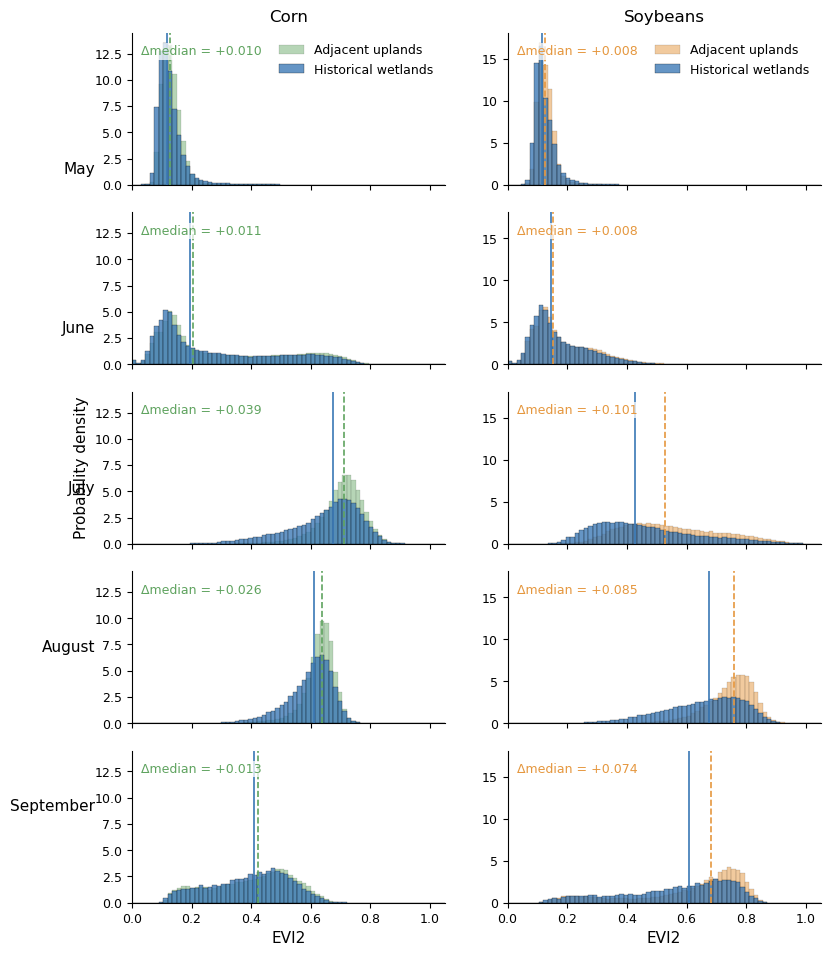

In [1]:
#!/usr/bin/env python3
"""
Figure 3 — Seasonal trajectories of crop canopy greenness (EVI2/NDVI)
Historical wetlands vs adjacent upland zones, shown as probability density histograms.

Polish + interpretability upgrades (publication-focused):
  - Row labels (months) moved to the LEFT margin (no repeated month text in every panel)
  - Clean, consistent legend per column (only once)
  - Wetlands visually foregrounded (slightly stronger alpha + edge), uplands slightly lighter
  - Median lines + explicit Δmedian annotation (upland − wetland) in each panel
  - Consistent y-scales within each crop column (set after plotting)
  - High-res outputs as both PNG and PDF
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ---------------------
# USER SETTINGS
# ---------------------
YEAR   = 2018
MONTHS = ["05", "06", "07", "08", "09"]  # May–Sept
LABELS = {"05": "May", "06": "June", "07": "July", "08": "August", "09": "September"}

# Options: "NDVI" or "EVI2"
METRIC = "EVI2"
if METRIC not in {"NDVI", "EVI2"}:
    raise ValueError("METRIC must be 'NDVI' or 'EVI2'.")

ROOT       = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
POOLED_DIR = ROOT / "NDVI_wetlands"

OUTDIR = ROOT / "Figures" / "Figure_3"
OUTDIR.mkdir(parents=True, exist_ok=True)
OUTPNG = OUTDIR / f"Figure3_{METRIC}_{YEAR}.png"
OUTPDF = OUTDIR / f"Figure3_{METRIC}_{YEAR}.pdf"

# Layout / style
FIGSIZE = (8.2, 10.0)  # slightly wider than before
BINS = np.linspace(0.0, 1.05, 71)  # 70 bins
X_LIM = (0.0, 1.05)

# Colors (keep your palette)
WETLAND_COLOR  = "#3A78B5"  # blue
CORN_ADJ_COLOR = "#5FA35F"  # green
SOY_ADJ_COLOR  = "#E5973E"  # orange

# Publication defaults (safe, journal-friendly)
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
    "savefig.dpi": 300,
})

# Subtle edges: enough to separate overlap, not "barcode"
EDGE_WET = dict(edgecolor="black", linewidth=0.25)
EDGE_UPL = dict(edgecolor="black", linewidth=0.15)


def get_value_columns(df: pd.DataFrame, metric: str):
    """Return (wet_col, upl_col) to use for plotting."""
    if metric == "NDVI":
        return "wet_med", "upl_med"

    # METRIC == "EVI2"
    wet_candidates = ["wet_evi2_med", "wet_e2_med"]
    upl_candidates = ["upl_evi2_med", "upl_e2_med"]

    wet_col = next((c for c in wet_candidates if c in df.columns), None)
    upl_col = next((c for c in upl_candidates if c in df.columns), None)

    if wet_col is None or upl_col is None:
        raise KeyError(
            f"Could not find EVI2 median columns. "
            f"Looked for wet in {wet_candidates}, upl in {upl_candidates}. "
            f"Columns present: {list(df.columns)}"
        )

    return wet_col, upl_col


def load_pooled(year: int, month: str, crop: str) -> pd.DataFrame | None:
    """
    Read the pooled CSV (one row per wetland, dir=='ALL').
    Adds 'wet_val' and 'upl_val' columns to use for plotting.
    """
    path = POOLED_DIR / f"upland_rasteronly_{crop}_{year}_{month}_pooled.csv"
    if not path.exists():
        print(f"[SKIP] Missing pooled CSV for {year}-{month} {crop}: {path.name}")
        return None

    df = pd.read_csv(path)

    if "dir" in df.columns:
        df = df[df["dir"] == "ALL"].copy()

    wet_col, upl_col = get_value_columns(df, METRIC)

    df = df[np.isfinite(df[wet_col]) & np.isfinite(df[upl_col])].copy()

    df["wet_val"] = df[wet_col].astype(float)
    df["upl_val"] = df[upl_col].astype(float)
    df["month"] = month
    df["crop"]  = crop
    return df


def annotate_delta(ax, w_med, u_med, color_upl, ypos=0.90):
    """
    Add a small, consistent Δmedian (upland - wetland) annotation.
    Uses axis coordinates so it stays in the same place across y-scales.
    """
    d = u_med - w_med
    # keep to 3 decimals; adjust if you prefer 2
    txt = f"Δmedian = {d:+.3f}"
    ax.text(
        0.03, ypos, txt,
        transform=ax.transAxes,
        ha="left", va="top",
        color=color_upl,
        fontsize=9,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.2),
        zorder=10
    )


# ---------------------
# Load data
# ---------------------
corn_dfs, soy_dfs = [], []
for mm in MONTHS:
    corn = load_pooled(YEAR, mm, "corn")
    soy  = load_pooled(YEAR, mm, "soy")
    if corn is not None:
        corn_dfs.append(corn)
    if soy is not None:
        soy_dfs.append(soy)

months_avail = sorted(set(
    [*( [d["month"].iloc[0] for d in corn_dfs] if corn_dfs else [] ),
     *( [d["month"].iloc[0] for d in soy_dfs]  if soy_dfs  else [] )]
))

if not months_avail:
    raise RuntimeError(
        f"No pooled CSVs found for the requested months for {METRIC}. "
        f"Check pooled CSVs exist in {POOLED_DIR}."
    )

def get_df(crop: str, month: str) -> pd.DataFrame | None:
    lst = corn_dfs if crop == "corn" else soy_dfs
    for d in lst:
        if d["month"].iloc[0] == month:
            return d
    return None


# ---------------------
# Figure
# ---------------------
nrows = len(months_avail)
fig, axes = plt.subplots(
    nrows=nrows, ncols=2,
    figsize=FIGSIZE,
    sharex=True,
)

# Column titles
axes[0, 0].set_title("Corn", pad=8)
axes[0, 1].set_title("Soybeans", pad=8)

# We will set y-lims after plotting
corn_ymax = 0.0
soy_ymax  = 0.0

# Plot rows
for r, mm in enumerate(months_avail):
    month_name = LABELS.get(mm, mm)

    # =========================
    # Corn (left)
    # =========================
    ax = axes[r, 0]
    dfc = get_df("corn", mm)

    if dfc is not None and not dfc.empty:
        wet_vals = dfc["wet_val"].to_numpy()
        upl_vals = dfc["upl_val"].to_numpy()

        # Uplands first (background), then wetlands (foreground)
        ax.hist(
            upl_vals, bins=BINS, density=True,
            color=CORN_ADJ_COLOR, alpha=0.45,
            zorder=1, label="Adjacent uplands" if r == 0 else None,
            **EDGE_UPL
        )
        ax.hist(
            wet_vals, bins=BINS, density=True,
            color=WETLAND_COLOR, alpha=0.78,
            zorder=2, label="Historical wetlands" if r == 0 else None,
            **EDGE_WET
        )

        # Medians
        w_med = float(np.median(wet_vals))
        u_med = float(np.median(upl_vals))
        ax.axvline(w_med, color=WETLAND_COLOR, linestyle="-",  linewidth=1.2, zorder=5)
        ax.axvline(u_med, color=CORN_ADJ_COLOR, linestyle="--", linewidth=1.2, zorder=5)

        annotate_delta(ax, w_med, u_med, color_upl=CORN_ADJ_COLOR, ypos=0.92)

        corn_ymax = max(corn_ymax, ax.get_ylim()[1])

        print(f"[{YEAR}-{mm}] {METRIC} Corn — wetlands n={len(wet_vals):,}, uplands n={len(upl_vals):,}")
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)

    # =========================
    # Soy (right)
    # =========================
    ax = axes[r, 1]
    dfs = get_df("soy", mm)

    if dfs is not None and not dfs.empty:
        wet_vals = dfs["wet_val"].to_numpy()
        upl_vals = dfs["upl_val"].to_numpy()

        # Uplands first (background), then wetlands (foreground)
        ax.hist(
            upl_vals, bins=BINS, density=True,
            color=SOY_ADJ_COLOR, alpha=0.50,
            zorder=1, label="Adjacent uplands" if r == 0 else None,
            **EDGE_UPL
        )
        ax.hist(
            wet_vals, bins=BINS, density=True,
            color=WETLAND_COLOR, alpha=0.78,
            zorder=2, label="Historical wetlands" if r == 0 else None,
            **EDGE_WET
        )

        # Medians
        w_med = float(np.median(wet_vals))
        u_med = float(np.median(upl_vals))
        ax.axvline(w_med, color=WETLAND_COLOR, linestyle="-",  linewidth=1.2, zorder=5)
        ax.axvline(u_med, color=SOY_ADJ_COLOR, linestyle="--", linewidth=1.2, zorder=5)

        annotate_delta(ax, w_med, u_med, color_upl=SOY_ADJ_COLOR, ypos=0.92)

        soy_ymax = max(soy_ymax, ax.get_ylim()[1])

        print(f"[{YEAR}-{mm}] {METRIC} Soy  — wetlands n={len(wet_vals):,}, uplands n={len(upl_vals):,}")
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)


# ---------------------
# Axes formatting
# ---------------------
# x-limits + clean spines
for ax in axes.ravel():
    ax.set_xlim(*X_LIM)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Consistent y-axis per crop column
for r in range(nrows):
    axes[r, 0].set_ylim(0, corn_ymax * 1.02)
    axes[r, 1].set_ylim(0, soy_ymax  * 1.02)

# Labels (single y-label on left column center)
mid_r = int(np.floor(nrows / 2))
axes[mid_r, 0].set_ylabel("Probability density")
axes[-1, 0].set_xlabel(METRIC)
axes[-1, 1].set_xlabel(METRIC)

# Legends: one per column, only on top row, consistent label text
axes[0, 0].legend(frameon=False, loc="upper right", title=None)
axes[0, 1].legend(frameon=False, loc="upper right", title=None)

# Row labels (months) on LEFT margin, aligned to each row center
# (This is the big readability win.)
fig.canvas.draw()  # ensure positions are available
for r, mm in enumerate(months_avail):
    month_name = LABELS.get(mm, mm)
    # Use the left axis position to place text outside plots
    bbox = axes[r, 0].get_position()
    y_center = (bbox.y0 + bbox.y1) / 2
    fig.text(
        bbox.x0 - 0.03, y_center, month_name,
        ha="right", va="center",
        fontsize=11
    )

# Tighten layout while preserving left margin for month labels
fig.subplots_adjust(left=0.14, right=0.98, top=0.95, bottom=0.08, wspace=0.20, hspace=0.18)

# Save
fig.savefig(OUTPNG, bbox_inches="tight")
fig.savefig(OUTPDF, bbox_inches="tight")
print(f"[OK] Saved → {OUTPNG}")
print(f"[OK] Saved → {OUTPDF}")


[2018-05] EVI2 Corn — wetlands n=72,391, upland-pooled n=72,391
[2018-05] EVI2 Soy — wetlands n=47,986, upland-pooled n=47,986
[2018-06] EVI2 Corn — wetlands n=68,425, upland-pooled n=68,425
[2018-06] EVI2 Soy — wetlands n=45,289, upland-pooled n=45,289
[2018-07] EVI2 Corn — wetlands n=72,406, upland-pooled n=72,406
[2018-07] EVI2 Soy — wetlands n=47,967, upland-pooled n=47,967
[2018-08] EVI2 Corn — wetlands n=72,389, upland-pooled n=72,389
[2018-08] EVI2 Soy — wetlands n=47,986, upland-pooled n=47,986
[2018-09] EVI2 Corn — wetlands n=15,300, upland-pooled n=15,300
[2018-09] EVI2 Soy — wetlands n=10,285, upland-pooled n=10,285
[OK] Saved → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/Figures/Figure 4/Figure 4.jpg


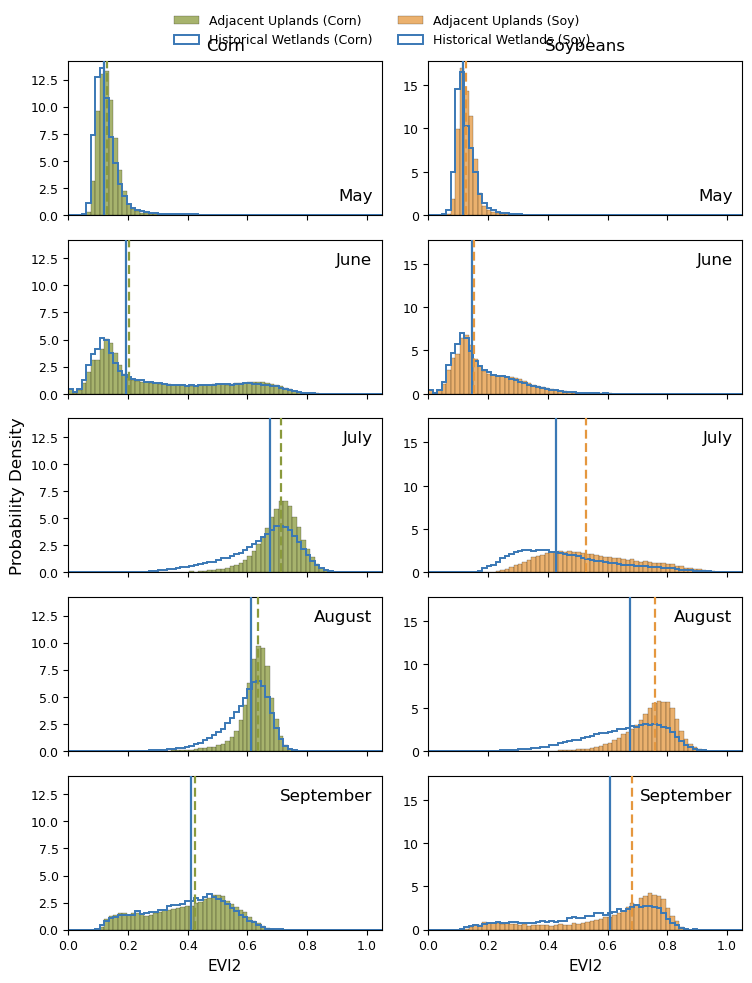

In [7]:
#!/usr/bin/env python3
# Monthly wetland vs upland EVI2 (or NDVI) PDFs (histograms with density=True)
# Drop-in script (fixes indent errors) + your new styling choice:
#   - Historical wetlands = BLUE outline (step)
#   - Adjacent uplands = FILLED (Corn=olive, Soy=orange)
#   - Stable y scaling by crop column
#   - Optional Δmedian annotation

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ---------------------
# USER SETTINGS
# ---------------------
YEAR   = 2018
MONTHS = ["05", "06", "07", "08", "09"]  # May–Sept
LABELS = {"05":"May","06":"June","07":"July","08":"August","09":"September"}

METRIC = "EVI2"         # "NDVI" or "EVI2"
SHOW_DELTA = False      # set True to annotate Δmedian (upland - wetland) per panel

if METRIC not in {"NDVI", "EVI2"}:
    raise ValueError("METRIC must be 'NDVI' or 'EVI2'.")

ROOT       = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
POOLED_DIR = ROOT / "NDVI_wetlands"

OUTFIG = ROOT / "Figures" / "Figure 4" / "Figure 4.jpg"
OUTFIG.parent.mkdir(parents=True, exist_ok=True)

FIGSIZE = (7.5, 10.0)
BINS = np.linspace(0.0, 1.05, 71)  # 70 bins
X_LIM = (0.0, 1.05)

# Colors
WETLAND_COLOR  = "#3A78B5"  # blue (outline)
CORN_ADJ_COLOR = "#8A9A3C"  # olive / yellow-green (filled)
SOY_ADJ_COLOR  = "#E5973E"  # orange (filled)

# Style: subtle, print-friendly
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
})

# Filled uplands: light edge so bars remain crisp in print
EDGE_UPL = dict(edgecolor="black", linewidth=0.20)

# Wetland outline width
WET_STEP_LW = 1.4


def get_value_columns(df: pd.DataFrame, metric: str):
    """Return (wet_col, upl_col) to use for plotting."""
    if metric == "NDVI":
        return "wet_med", "upl_med"

    wet_candidates = ["wet_evi2_med", "wet_e2_med"]
    upl_candidates = ["upl_evi2_med", "upl_e2_med"]

    wet_col = next((c for c in wet_candidates if c in df.columns), None)
    upl_col = next((c for c in upl_candidates if c in df.columns), None)

    if wet_col is None or upl_col is None:
        raise KeyError(
            f"Could not find EVI2 median columns. "
            f"Looked for wet in {wet_candidates}, upl in {upl_candidates}. "
            f"Columns present: {list(df.columns)}"
        )

    return wet_col, upl_col


def load_pooled(year: int, month: str, crop: str) -> pd.DataFrame | None:
    """
    Read pooled CSV (one row per wetland, usually filtered to dir=='ALL').
    Adds 'wet_val' and 'upl_val' columns for plotting.
    """
    path = POOLED_DIR / f"upland_rasteronly_{crop}_{year}_{month}_pooled.csv"
    if not path.exists():
        print(f"[SKIP] Missing pooled CSV for {year}-{month} {crop}: {path.name}")
        return None

    df = pd.read_csv(path)

    if "dir" in df.columns:
        df = df[df["dir"] == "ALL"].copy()

    wet_col, upl_col = get_value_columns(df, METRIC)
    df = df[np.isfinite(df[wet_col]) & np.isfinite(df[upl_col])].copy()

    df["wet_val"] = df[wet_col].astype(float)
    df["upl_val"] = df[upl_col].astype(float)
    df["month"] = month
    df["crop"]  = crop
    return df


def pdf_max(vals, bins):
    """Compute max PDF height over bins (density=True equivalent)."""
    h, _ = np.histogram(vals, bins=bins, density=True)
    return float(np.nanmax(h)) if len(h) else 0.0


def get_month_label_pos(month_name: str):
    """Your rule: May label bottom-right; others top-right."""
    if month_name == "May":
        return 0.97, 0.08, "bottom"
    return 0.97, 0.92, "top"


# ---------------------
# Load data
# ---------------------
corn_dfs, soy_dfs = [], []
for mm in MONTHS:
    corn = load_pooled(YEAR, mm, "corn")
    soy  = load_pooled(YEAR, mm, "soy")
    if corn is not None:
        corn_dfs.append(corn)
    if soy is not None:
        soy_dfs.append(soy)

months_avail = sorted(set(
    [*( [d["month"].iloc[0] for d in corn_dfs] if corn_dfs else [] ),
     *( [d["month"].iloc[0] for d in soy_dfs]  if soy_dfs  else [] )]
))

if not months_avail:
    raise RuntimeError(
        f"No pooled CSVs found for the requested months for {METRIC}. "
        f"Check that pooled CSVs exist in {POOLED_DIR}."
    )


def get_df(crop: str, month: str) -> pd.DataFrame | None:
    lst = corn_dfs if crop == "corn" else soy_dfs
    for d in lst:
        if d["month"].iloc[0] == month:
            return d
    return None


# ---------------------
# Stable y scaling per crop column
# ---------------------
corn_ymax = 0.0
soy_ymax  = 0.0
for mm in months_avail:
    dfc = get_df("corn", mm)
    if dfc is not None and not dfc.empty:
        corn_ymax = max(
            corn_ymax,
            pdf_max(dfc["wet_val"].values, BINS),
            pdf_max(dfc["upl_val"].values, BINS),
        )
    dfs = get_df("soy", mm)
    if dfs is not None and not dfs.empty:
        soy_ymax = max(
            soy_ymax,
            pdf_max(dfs["wet_val"].values, BINS),
            pdf_max(dfs["upl_val"].values, BINS),
        )

corn_ymax *= 1.05
soy_ymax  *= 1.05


# ---------------------
# Figure
# ---------------------
nrows = len(months_avail)
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=FIGSIZE, sharex=True)
if nrows == 1:
    axes = np.array([axes])  # keep 2D

# Column titles
axes[0, 0].set_title("Corn", fontsize=12, pad=8)
axes[0, 1].set_title("Soybeans", fontsize=12, pad=8)

# Plot
for r, mm in enumerate(months_avail):
    month_name = LABELS.get(mm, mm)
    x_pos, y_pos, va = get_month_label_pos(month_name)

    # =========================
    # Corn
    # =========================
    ax = axes[r, 0]
    dfc = get_df("corn", mm)

    # Month label
    ax.text(
        x_pos, y_pos, month_name,
        transform=ax.transAxes,
        fontsize=12,
        ha="right",
        va=va,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.2),
        zorder=10,
    )

    if dfc is not None and not dfc.empty:
        wet_vals = dfc["wet_val"].values
        upl_vals = dfc["upl_val"].values

        # Uplands (FILLED)
        ax.hist(
            upl_vals,
            bins=BINS,
            density=True,
            histtype="bar",
            color=CORN_ADJ_COLOR,
            alpha=0.75,
            zorder=1,
            label="Adjacent Uplands (Corn)" if r == 0 else None,
            **EDGE_UPL,
        )

        # Historical wetlands (OUTLINE)
        ax.hist(
            wet_vals,
            bins=BINS,
            density=True,
            histtype="step",
            color=WETLAND_COLOR,
            linewidth=WET_STEP_LW,
            zorder=2,
            label="Historical Wetlands (Corn)" if r == 0 else None,
        )

        # Median lines
        w_med = np.median(wet_vals)
        u_med = np.median(upl_vals)
        ax.axvline(w_med, color=WETLAND_COLOR, linestyle="-", linewidth=1.6, zorder=5)
        ax.axvline(u_med, color=CORN_ADJ_COLOR, linestyle=(0, (4, 2)), linewidth=1.6, zorder=5)

        if SHOW_DELTA:
            d = u_med - w_med
            ax.text(
                0.03, 0.92, f"Δmedian={d:+.3f}",
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=9,
                color=CORN_ADJ_COLOR,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.0),
                zorder=10,
            )

        print(f"[{YEAR}-{mm}] {METRIC} Corn — wetlands n={len(wet_vals):,}, upland-pooled n={len(upl_vals):,}")
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)

    ax.set_xlim(*X_LIM)
    ax.set_ylim(0, corn_ymax)

    if r == int(np.floor(nrows / 2)):
        ax.set_ylabel("Probability Density", fontsize=12)
    if r == nrows - 1:
        ax.set_xlabel(METRIC, fontsize=11)

    # =========================
    # Soy
    # =========================
    ax = axes[r, 1]
    dfs = get_df("soy", mm)

    # Month label
    ax.text(
        x_pos, y_pos, month_name,
        transform=ax.transAxes,
        fontsize=12,
        ha="right",
        va=va,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.2),
        zorder=10,
    )

    if dfs is not None and not dfs.empty:
        wet_vals = dfs["wet_val"].values
        upl_vals = dfs["upl_val"].values

        # Uplands (FILLED)
        ax.hist(
            upl_vals,
            bins=BINS,
            density=True,
            histtype="bar",
            color=SOY_ADJ_COLOR,
            alpha=0.75,
            zorder=1,
            label="Adjacent Uplands (Soy)" if r == 0 else None,
            **EDGE_UPL,
        )

        # Historical wetlands (OUTLINE)
        ax.hist(
            wet_vals,
            bins=BINS,
            density=True,
            histtype="step",
            color=WETLAND_COLOR,
            linewidth=WET_STEP_LW,
            zorder=2,
            label="Historical Wetlands (Soy)" if r == 0 else None,
        )

        # Median lines
        w_med = np.median(wet_vals)
        u_med = np.median(upl_vals)
        ax.axvline(w_med, color=WETLAND_COLOR, linestyle="-", linewidth=1.6, zorder=5)
        ax.axvline(u_med, color=SOY_ADJ_COLOR, linestyle=(0, (4, 2)), linewidth=1.6, zorder=5)

        if SHOW_DELTA:
            d = u_med - w_med
            ax.text(
                0.03, 0.92, f"Δmedian={d:+.3f}",
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=9,
                color=SOY_ADJ_COLOR,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.0),
                zorder=10,
            )

        print(f"[{YEAR}-{mm}] {METRIC} Soy — wetlands n={len(wet_vals):,}, upland-pooled n={len(upl_vals):,}")
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)

    ax.set_xlim(*X_LIM)
    ax.set_ylim(0, soy_ymax)

    if r == nrows - 1:
        ax.set_xlabel(METRIC, fontsize=11)

# ---------------------
# Shared legend (top center)
# ---------------------
handles0, labels0 = axes[0, 0].get_legend_handles_labels()
handles1, labels1 = axes[0, 1].get_legend_handles_labels()

handles = handles0 + handles1
labels  = labels0  + labels1

# In case some labels are None (shouldn't be), filter
handles_f, labels_f = [], []
for h, lab in zip(handles, labels):
    if lab:
        handles_f.append(h)
        labels_f.append(lab)

fig.legend(
    handles_f,
    labels_f,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.985),
)

# Spacing: leave room for legend
fig.tight_layout(rect=[0, 0, 1, 0.965], w_pad=1.5, h_pad=1.2)

fig.savefig(OUTFIG, dpi=300, bbox_inches="tight")
print(f"[OK] Saved → {OUTFIG}")
